## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в барнку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

In [1]:
import utils
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, precision_recall_curve
from sklearn.metrics import f1_score, classification_report, average_precision_score, recall_score
from sklearn.metrics import roc_curve, auc
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
raw_data = pd.read_csv('bank-additional-full.csv', sep=';')

# Exploratory Data Analysis

In [4]:
raw_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
raw_data.shape

(41188, 21)

In [6]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
print("Target distribution:")
print(raw_data['y'].value_counts(normalize=True))
print(raw_data['y'].value_counts())

Target distribution:
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64
y
no     36548
yes     4640
Name: count, dtype: int64


Набір даних містить 41188 рядків та 21 стовпець. В наборі даних є числові та категоріальні стовпці. Набір даних не містить пропущених значень.
Цільова змінна розподілена не рівномірно(приблизно 89% no, та 11% yes).

In [8]:
raw_data.duplicated().sum()

np.int64(12)

In [9]:
raw_data[raw_data.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [10]:
raw_data = raw_data.drop_duplicates()
raw_data.shape

(41176, 21)

У датасеті виявлено та видалено 12 повних дублікатів (повністю ідентичні записи за всіма ознаками та цільовою змінною).

In [11]:
raw_data.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


Типи даних в стобцях виглядають вірними, нічого змінювати не будемо

Дані містять 10 числових і 10 категріальних змінних


In [12]:
raw_data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**Спостреження по числових колонках:**

* Змінна pdays містить спеціальне значення 999, що означає відсутність попередніх контактів. Більш ніж 75% спостережень мають таке значення, що вказує на перважність нових клієнтів. Це спричиняє сильну асиметрію розподілу і спотворенню середнього значення.
* Змінна previous пітверджує цей патерн: 75% клієнтів не мали попердніх контактів
* Змінна duration демонструє дуже сильний зв'язок із цільовою змінною. Однак тривалість дзвінка стає відомою лише після його завершення, тому використання цього параметра призводить до витоку даних (data leakage). Через це дана змінна буде використовуватися лише для порівняння моделей і не включатиметься до фінальної моделі прогнозування.
* в колонках age, duration, campaign є викиди

**Спостреження по макроекономічних показниках**

* emp.var.rate: має переважно додатні значення, що вказує на періоди зростання зайнятості в економіц
* cons.price.idx: має відносно невеликий розкид значень, що свідчить про стабільність цінових коливань у період спостереженн
* cons.conf.idx: всі значення від'ємні, що вказує на переважно песимістичні споживчі настрої протягом періоду кампанії
* euribor3m: відображає рівень відсоткових ставок на фінансовому ринку, який потенційно може впливати на привабливість строкових депозитів для клієнтів

Усі ці макроекономічні змінні є однаковими для груп клієнтів у певні періоди часу та відображають загальний економічний контекст, у якому проводилась маркетингова кампанія

In [13]:
input_cols = raw_data.columns.drop('y')
target_col = 'y'
numeric_cols = raw_data[input_cols].select_dtypes(include='number').columns.tolist()
categorical_cols = raw_data[input_cols].select_dtypes('object').columns.tolist()
print(f'Numeric columns: {numeric_cols}')
print(f'Categorical columns: {categorical_cols}')

Numeric columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [14]:
print(f'Numeric columns count: {len(numeric_cols)}')
print(f'Categorical columns count: {len(categorical_cols)}')

Numeric columns count: 10
Categorical columns count: 10


**Аналіз числових ознак**

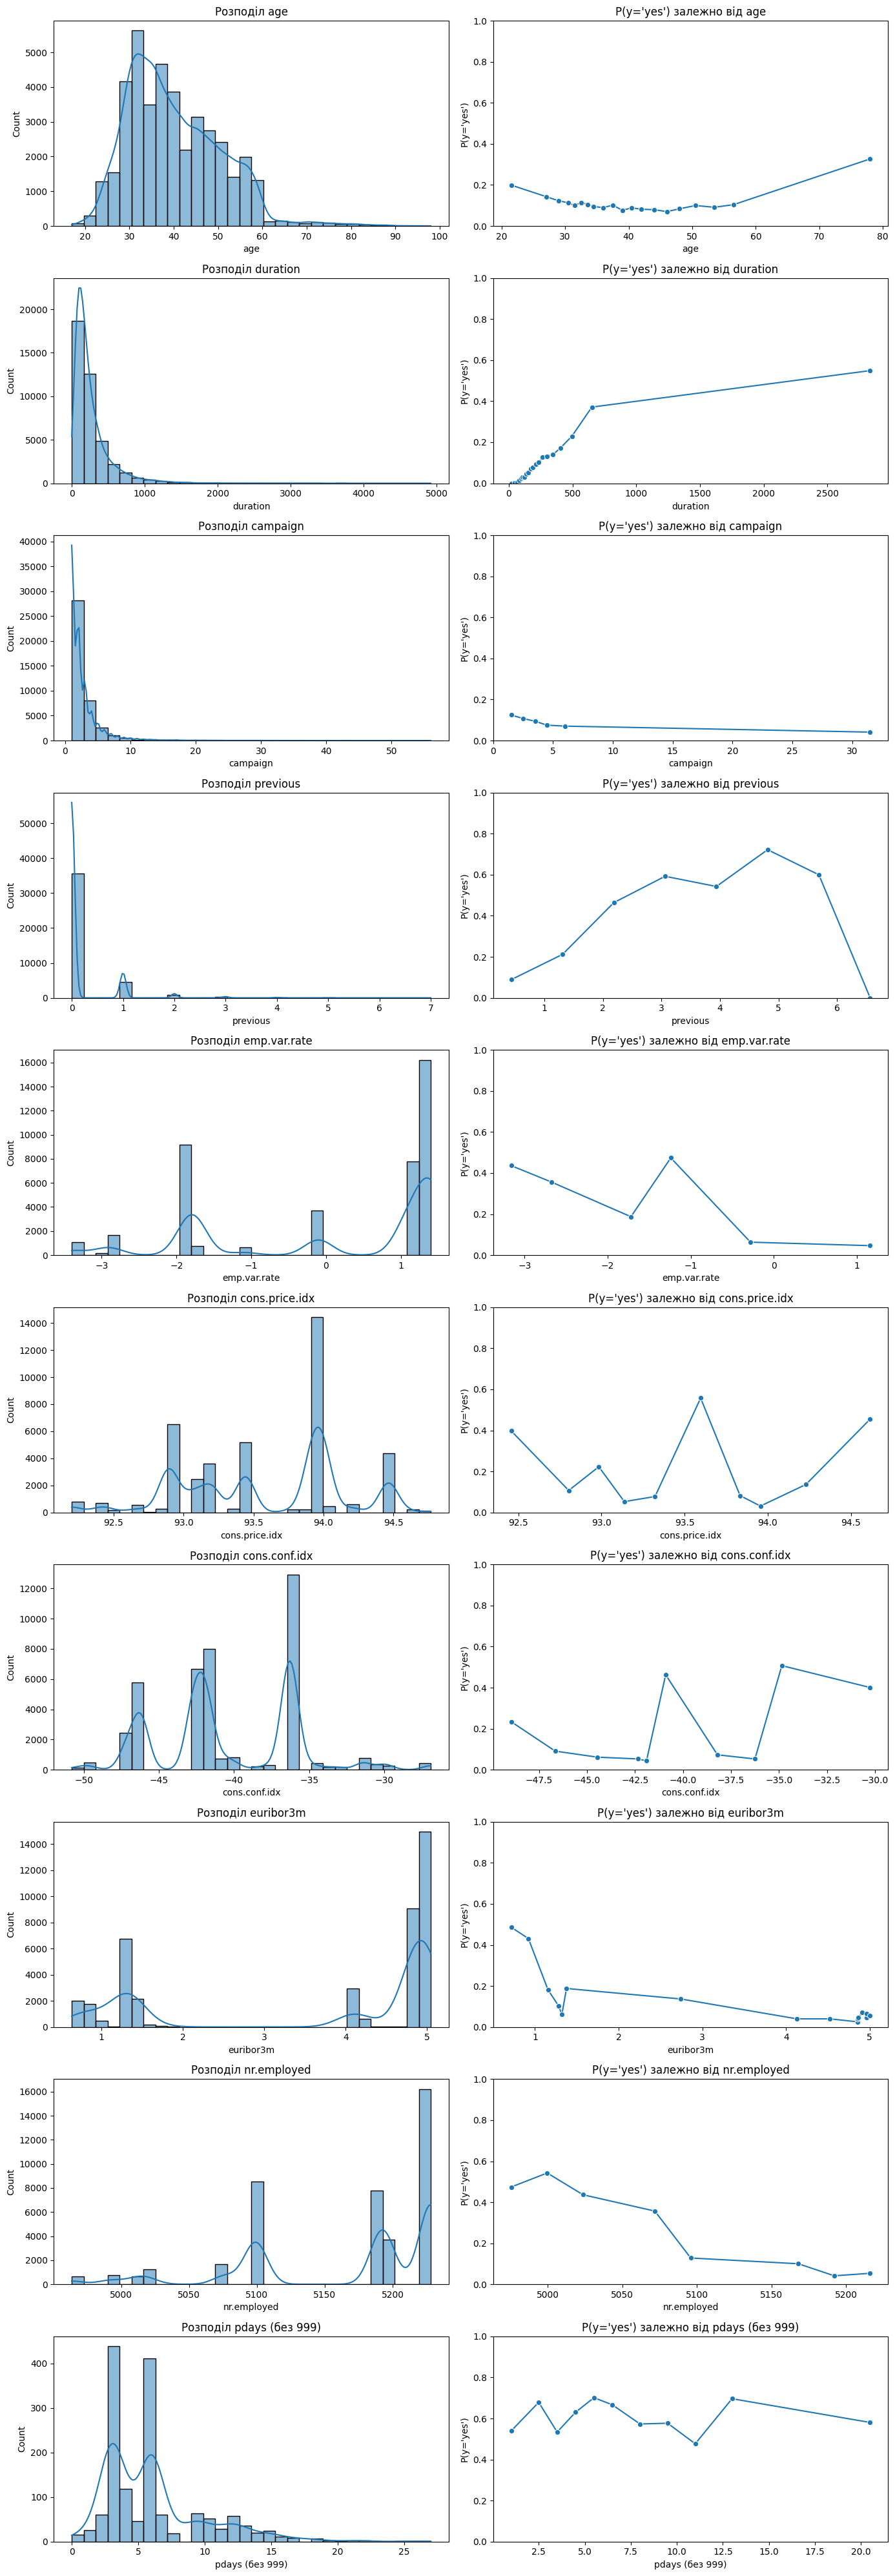

In [15]:
# Візуалізація розподілу числових ознак + залежність P(y=yes) від значення
df_viz = raw_data.copy()

# pdays: 999 = "не контактували раніше" → для графіків краще прибрати в NaN
df_viz['pdays_clean'] = df_viz['pdays'].replace(999, np.nan)

def plot_numeric_block(df, features, target='y', bins=30, rename=None, q=20):
    """
    Для кожної числової ознаки будує:
    1) Histogram (+ KDE) розподілу значень
    2) Графік P(y='yes') по бінованих значеннях ознаки (qcut / cut)

    q — кількість бінів для графіка ймовірності (краще 15-30).
    """
    n = len(features)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))
    if n == 1:
        axes = np.array([axes])

    y_yes = (df[target] == 'yes').astype(int)

    for i, f in enumerate(features):
        display_name = rename.get(f, f) if rename else f

        # 1) Розподіл
        sns.histplot(df[f].dropna(), bins=bins, kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f"Розподіл {display_name}")
        axes[i, 0].set_xlabel(display_name)

        # 2) P(y=yes) vs значення (через біни)
        x = df[f]

        # якщо дуже мало унікальних значень — робимо звичайні cut, інакше qcut
        try:
            if x.nunique(dropna=True) <= q:
                binned = pd.cut(x, bins=min(q, x.nunique(dropna=True)))
            else:
                binned = pd.qcut(x, q=q, duplicates='drop')
        except Exception:
            # fallback на випадок проблем з qcut (однакові значення тощо)
            binned = pd.cut(x, bins=q)

        rate = (
            pd.DataFrame({'bin': binned, 'y_yes': y_yes})
            .dropna(subset=['bin'])
            .groupby('bin', observed=True)['y_yes']
            .mean()
            .reset_index()
        )

        # X як середина інтервалу для нормального lineplot
        def midpoint(interval):
            return (interval.left + interval.right) / 2

        rate['x_mid'] = rate['bin'].apply(midpoint)

        sns.lineplot(data=rate, x='x_mid', y='y_yes', marker='o', ax=axes[i, 1])
        axes[i, 1].set_title(f"P(y='yes') залежно від {display_name}")
        axes[i, 1].set_xlabel(display_name)
        axes[i, 1].set_ylabel("P(y='yes')")
        axes[i, 1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()


# Список числових ознак: прибираємо pdays, додаємо pdays_clean
features = [c for c in numeric_cols if c != "pdays"] + ["pdays_clean"]
rename = {"pdays_clean": "pdays (без 999)"}

plot_numeric_block(df_viz, features, target='y', bins=30, rename=rename, q=20)

**Спостреження**

* Age: спостерігається нелінійна залежність між віком та ймовірністю підписання депозиту. Ймовірність є нижчою у середньому віковому діапазоні (приблизно 30–45 років) та вищою серед молодших і старших клієнтів. Лінійної залежності не виявлено
* Duration: спостерігається сильна позитивна залежність — чим довший дзвінок, тим вища ймовірність підписання договору. Проте цей показник відомий лише після завершення дзвінка, тому не може використовуватись у фінальній прогнозній моделі
* campaign: більшість клієнтів отримували 1–3 дзвінки. Спостерігається негативна залежність: зі збільшенням кількості контактів у межах поточної кампанії ймовірність підписання депозиту зменшується. Це може свідчити про те, що клієнти, яким телефонують багаторазово, менш схильні до прийняття пропозиції.
* privious: для більшості клієнтів значення дорівнює 0, що свідчить про переважання нових контактів. Водночас для клієнтів з 1–3 попередніми контактами спостерігається підвищена ймовірність підписання депозиту. Для більших значень показник стає нестабільним через малу кількість спостережень.
* pdays: аналіз проводився після виключення значення 999 (клієнти без попереднього контакту). Для клієнтів, з якими контакт уже відбувався, не спостерігається чіткої залежності між кількістю днів з останнього контакту та цільовою змінною.

Макроекономічні змінні (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed) відображають загальний економічний стан у період проведення маркетингових кампаній та є однаковими для груп клієнтів у межах одного часового інтервалу.

Під час аналізу спостерігаються відмінності у рівнях підписок між різними економічними періодами, що свідчить про потенційний вплив макроекономічного контексту на поведінку клієнтів. Водночас ці змінні мають часову природу та сильну взаємну кореляцію між собою, тому виявлені залежності слід інтерпретувати як асоціації, а не як прямі причинно-наслідкові зв’язки.

Таким чином, макроекономічні показники можуть надавати моделі додаткову інформацію про часові та економічні умови проведення кампаній, але потребують обережної інтерпретації результатів.

In [16]:
def plot_categorical_combined(df, feature, target='y'):
    summary = (
        df
        .groupby(feature)[target]
        .agg(['count', lambda x: (x == 'yes').mean()])
        .rename(columns={'<lambda_0>': 'p_yes'})
        .reset_index()
        .sort_values('p_yes', ascending=False)
    )

    fig, ax1 = plt.subplots(figsize=(12,6))

    sns.barplot(data=summary, x=feature, y='count', ax=ax1, alpha=0.6)
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)

    ax2 = ax1.twinx()
    sns.lineplot(data=summary, x=feature, y='p_yes', ax=ax2, marker='o', color='red')
    ax2.set_ylabel('P(y=yes)')

    plt.title(f'{feature}: розподіл + ймовірність yes')
    plt.show()


====== JOB ======


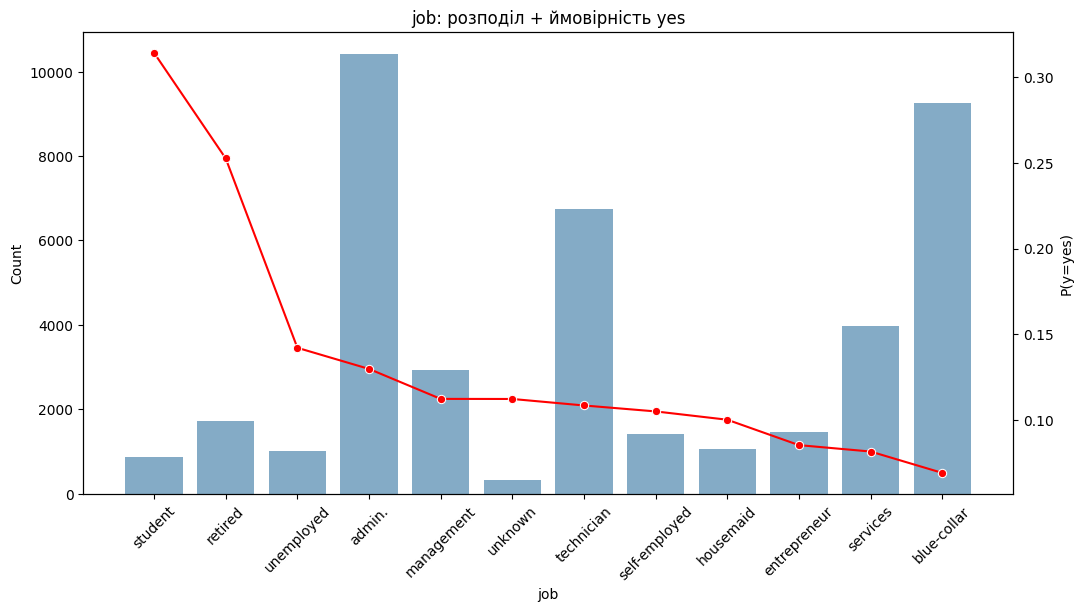


====== MARITAL ======


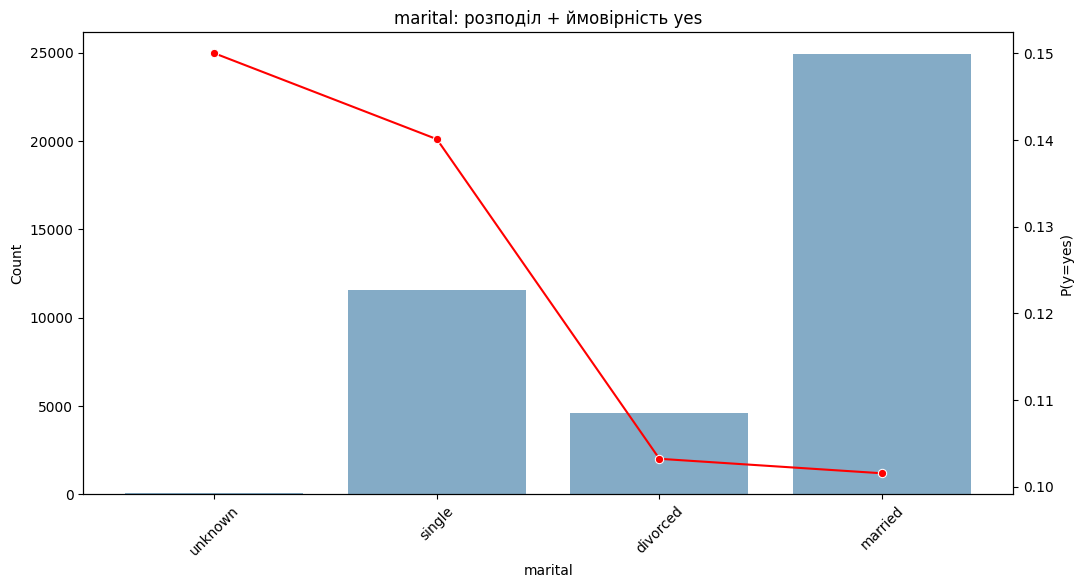


====== EDUCATION ======


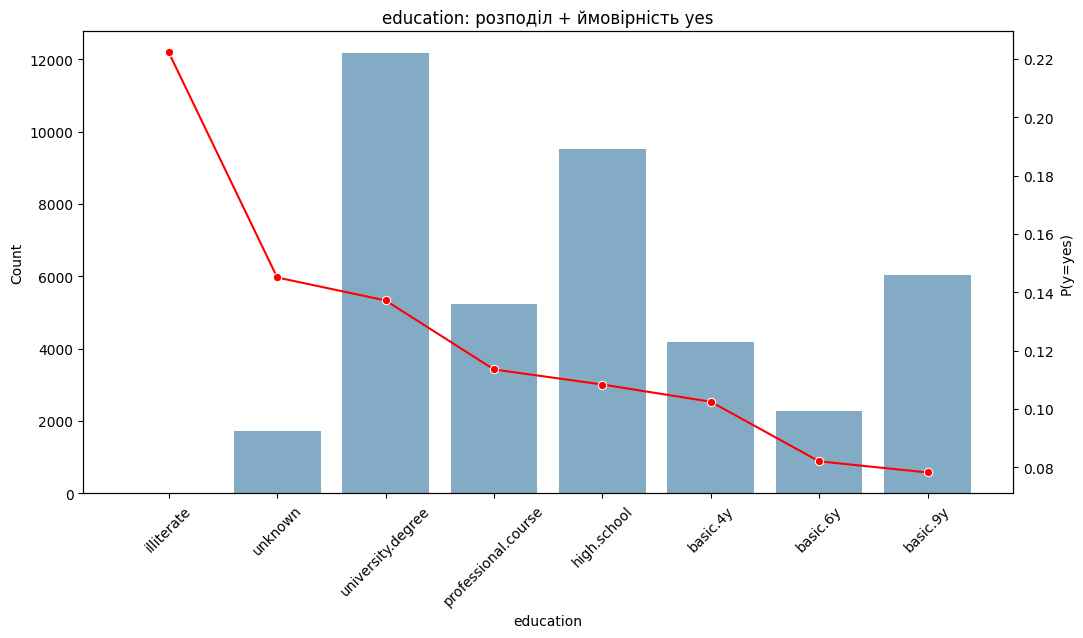


====== DEFAULT ======


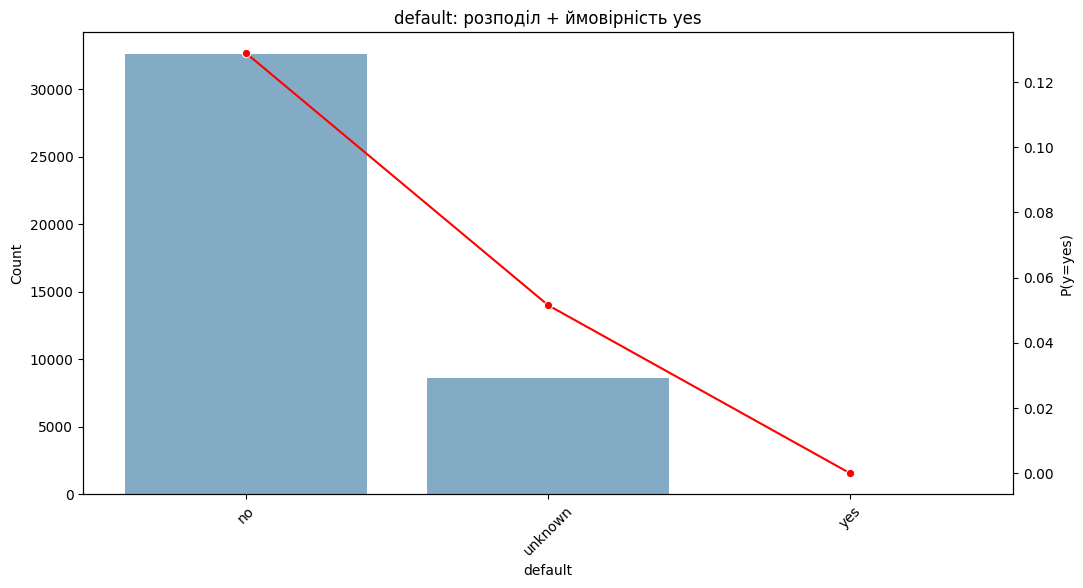


====== HOUSING ======


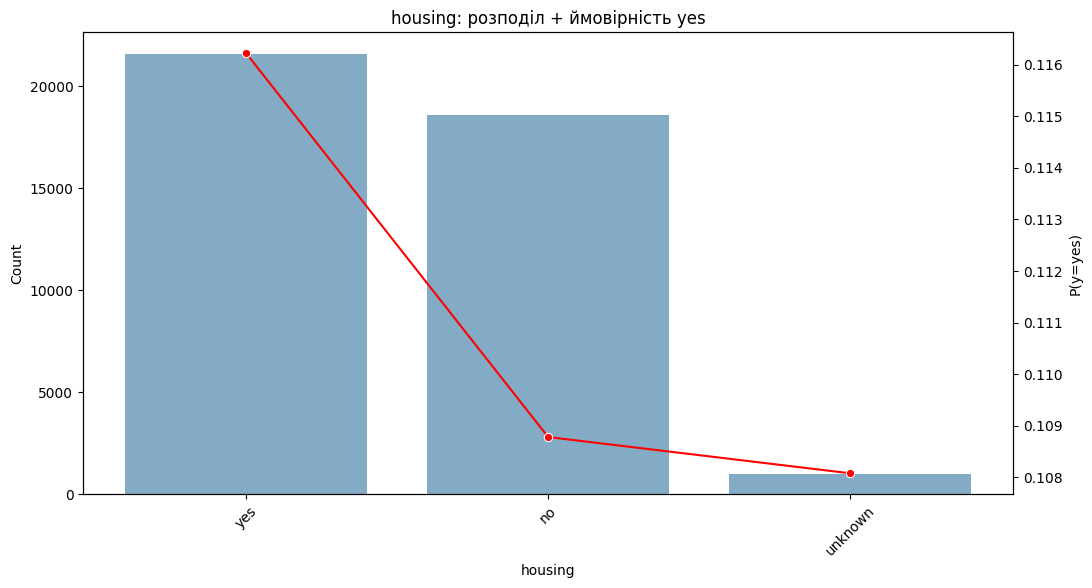


====== LOAN ======


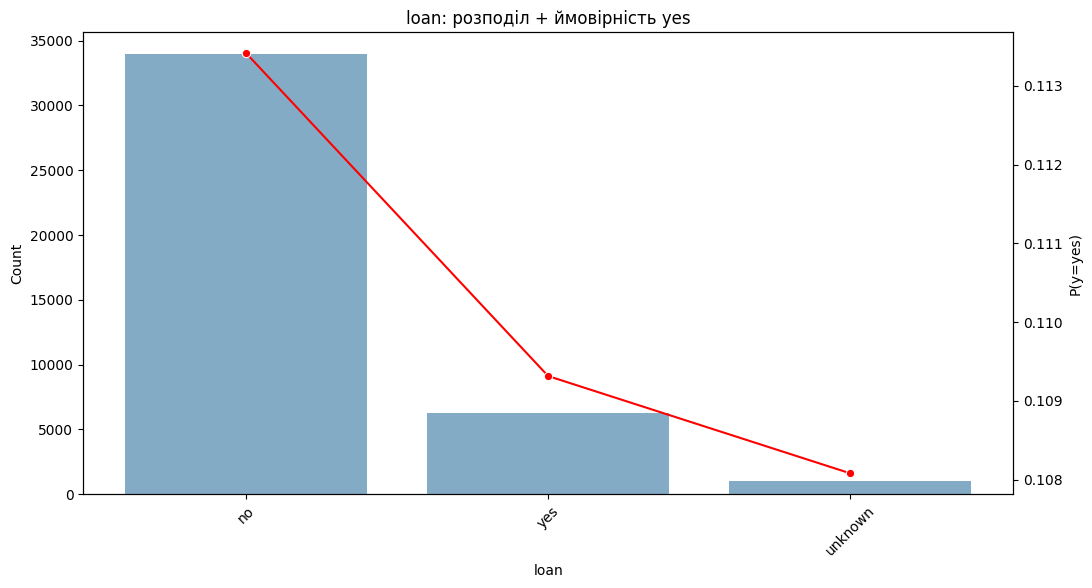


====== CONTACT ======


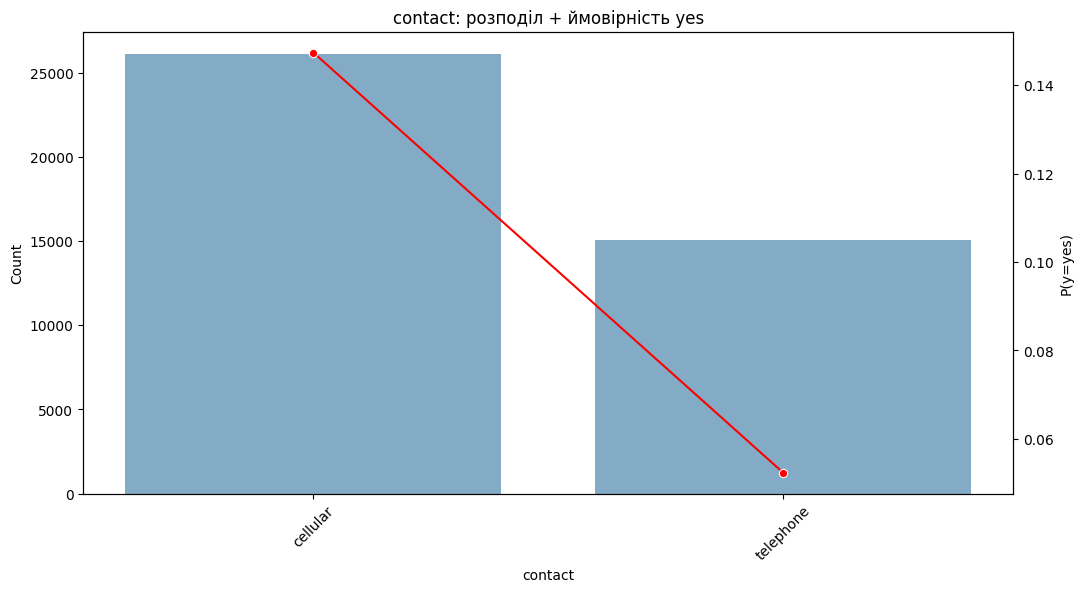


====== MONTH ======


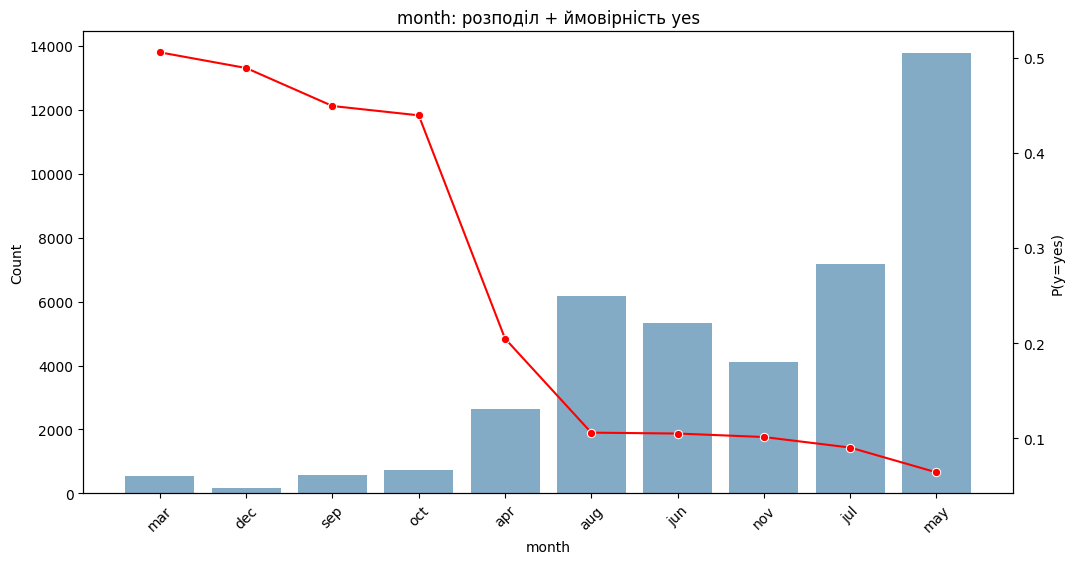


====== DAY_OF_WEEK ======


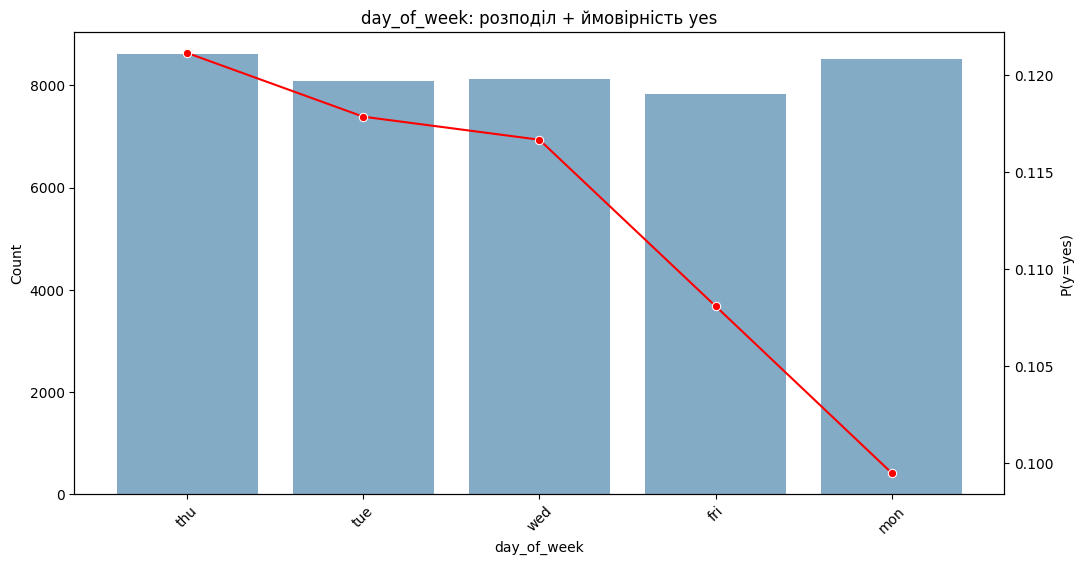


====== POUTCOME ======


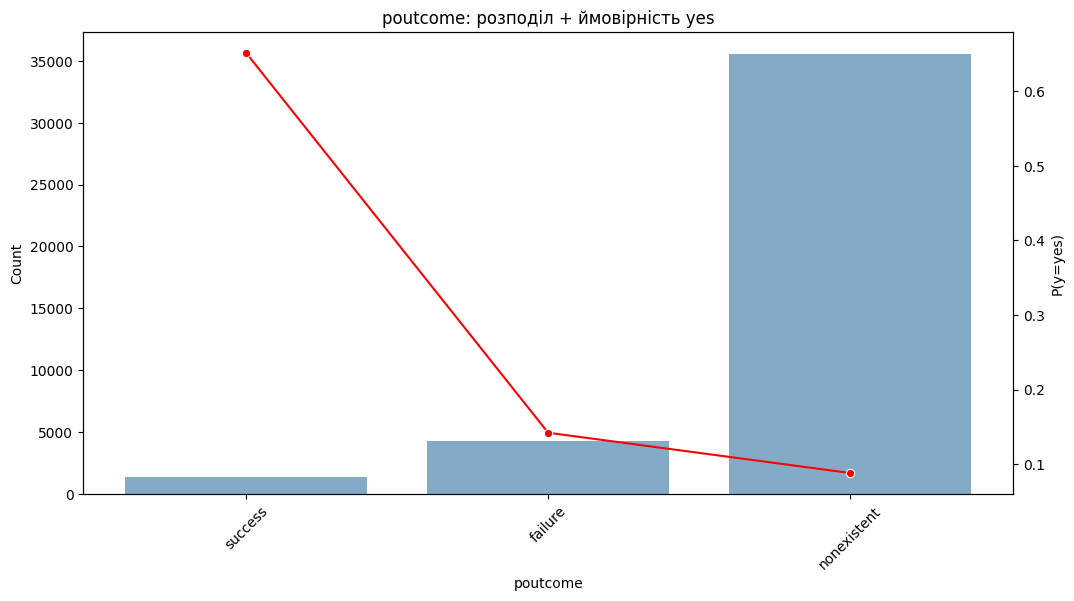

In [ ]:
for col in categorical_cols:
    print(f"\n====== {col.upper()} ======")
    plot_categorical_combined(raw_data, col)

**Спостредення по категоріальним ознакам**

* job: найвищу ймовірність підписання депозиту мають студенти та пенсіонери, тоді як клієнти з професією blue-collar демонструють найнижчу конверсію
* marital: ознака marital демонструє слабко-помірний вплив на ймовірність підписання депозиту. Клієнти зі статусом single та divorced мають дещо вищу конверсію порівняно з married. Різниця становить декілька процентних пунктів і є стабільною завдяки достатньому розміру груп
* education: клієнти з вищою освітою мають дещо вищу ймовірність підписання депозиту. Високі значення у рідкісних категоріях (наприклад, illiterate) можуть бути статистично нестабільними
* default: наявність кредитного дефолту асоціюється з дуже низькою ймовірністю підписання депозиту, проте група клієнтів з default=yes є малочисельною
* loan, housing: демонструють слабкий або практично выдсутній вплив на цільову змінну
* contact: доля погодившихся на підписання договору вища серед тих кому телефонували по мобільному зв'зку
* month: ознака month демонструє суттєву варіативність рівня підписок. У деяких місяцях спостерігається значно вища конверсія при меншій кількості контактів, що може відображати як сезонність, так і зміну стратегії кампаній. Дзвінки в грудні, березні, жовтні та вересні частіше призводили до підписання договру
* day_of_week: не демонструє суттєвого впливу на ймовірність підписання депозиту
* poutcome: клієнти з попереднім успішним контактом демонструють суттєво вищу ймовірність підписання депозиту

**Загальні висновки**

Найбільш інформативними ознаками є:

poutcome (попередній успішний контакт суттєво підвищує ймовірність підписання);

month, що відображає сезонність або різні стратегії кампаній;

duration (сильний вплив, але не використовується у фінальній моделі через витік інформації);

макроекономічні змінні (euribor3m, nr.employed, emp.var.rate), які відображають економічний контекст;

campaign та previous, що характеризують історію контактів із клієнтом.

Помірний вплив мають job, education та marital, тоді як housing, loan і day_of_week демонструють слабкий або мінімальний зв’язок із цільовою змінною.

**Для розв’язання задачі бінарної класифікації доцільно використати Logistic Regression, kNN, Decision Tree та Boosting. Через наявність дисбалансу класів основною метрикою обрано ROC-AUC, оскільки вона дозволяє оцінити здатність моделі розрізняти класи незалежно від порогу класифікації.**

# Data Preprocessing

Ознака pdays містить значення 999, яке означає відсутність попереднього контакту з клієнтом. Тому значення 999 було замінено на NaN, а також створено додаткову бінарну змінну was_contacted_before, що відображає факт попередньої взаємодії.

In [17]:
raw_data["was_contacted_before"] = (raw_data["pdays"] != 999).astype(int)
raw_data["pdays"] = raw_data["pdays"].replace(999, np.nan)

In [18]:
raw_data["pdays"].describe()

,pdays
count,1515.000000
mean,6.014521
std,3.824906
min,0.000000
25%,3.000000
50%,6.000000
75%,7.000000
max,27.000000


In [19]:
train_df, val_df = train_test_split(raw_data, test_size=0.25, random_state=RANDOM_STATE, stratify=raw_data['y'])

input_cols = train_df.columns.drop(['y', 'duration']).tolist()
target_col = 'y'

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [20]:
numeric_cols, categorical_cols

(['age',
  'campaign',
  'pdays',
  'previous',
  'emp.var.rate',
  'cons.price.idx',
  'cons.conf.idx',
  'euribor3m',
  'nr.employed',
  'was_contacted_before'],
 ['job',
  'marital',
  'education',
  'default',
  'housing',
  'loan',
  'contact',
  'month',
  'day_of_week',
  'poutcome'])

In [21]:
# Convert target variables to numerical values (0 and 1)
train_targets_numerical = train_targets.map({'no': 0, 'yes': 1})
val_targets_numerical = val_targets.map({'no': 0, 'yes': 1})

In [22]:
numeric_pipe_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_pipe_not_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_scaled = ColumnTransformer([
    ("num", numeric_pipe_scaled, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
])

preprocess_not_scaled = ColumnTransformer([
    ("num", numeric_pipe_not_scaled, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
])

In [23]:
SCORING = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "f1": "f1",
    "recall": "recall"
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Baseline Classic Models Training and Cross-Validation

In [24]:
baseline_pipelines = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocess_scaled),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "kNN": Pipeline([
        ("preprocess", preprocess_scaled),
        ("model", KNeighborsClassifier())
    ]),

    "Decision Tree": Pipeline([
        ("preprocess", preprocess_not_scaled),
        ("model", DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])
}

In [25]:
baseline_results = []

for model_name, pipeline in baseline_pipelines.items():
    result, fitted_model = utils.evaluate_model_full(
        model_name=model_name,
        estimator=pipeline,
        X_train=train_inputs,
        y_train=train_targets_numerical,
        X_valid=val_inputs,
        y_valid=val_targets_numerical,
        cv=cv,
        scoring=SCORING,
        approach="baseline",
        threshold=0.5
    )

    baseline_results.append(result)


In [26]:
# converting object types to categorical for XGBoost model
X_train_xgb = train_inputs.copy()
cat_features = X_train_xgb.select_dtypes(include='object').columns
X_train_xgb[cat_features] = train_inputs[cat_features].astype('category')

X_valid_xgb = val_inputs.copy()
X_valid_xgb[cat_features] = X_valid_xgb[cat_features].astype('category')

# ratio of negative class to the positive class
scale_pos_weight = (train_targets_numerical == 0).sum() / (train_targets_numerical == 1).sum()

In [27]:
xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    missing=np.nan,
    scale_pos_weight=scale_pos_weight
)

In [28]:
xgb_baseline_result, xgb_baseline_model = utils.evaluate_model_full(
    model_name="XGBoost",
    estimator=xgb_baseline,
    X_train=X_train_xgb,
    y_train=train_targets_numerical,
    X_valid=X_valid_xgb,
    y_valid=val_targets_numerical,
    cv=cv,
    scoring=SCORING,
    approach="baseline",
    threshold=0.5,
    n_jobs=1
)

baseline_results.append(xgb_baseline_result)

In [29]:
baseline_results_df = pd.DataFrame(baseline_results).sort_values(
    by="valid_roc_auc", ascending=False).reset_index(drop=True)
baseline_results_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
0,Logistic Regression,baseline,0.5,0.788458,0.446911,0.452343,0.622017,0.802032,0.443574,0.463316,0.639655,"{'C': 1.0, 'class_weight': 'balanced', 'dual':..."
1,XGBoost,baseline,0.5,0.773166,0.426212,0.447924,0.571140,0.790838,0.451555,0.472752,0.609483,"{'objective': 'binary:logistic', 'base_score':..."
2,kNN,baseline,0.5,0.722670,0.317488,0.371364,0.286287,0.739928,0.339067,0.373639,0.281034,"{'algorithm': 'auto', 'leaf_size': 30, 'metric..."
3,Decision Tree,baseline,0.5,0.622882,0.182910,0.325684,0.339469,0.614064,0.176315,0.312158,0.319828,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."


**Висновки по бейзлайн моделях:**

Було натреновано базові моделі з використанням крос-валідації: **Logistic Regression, Decision Tree, k-Nearest Neighbors та XGBoost**. Порівняння моделей проводилось за основною метрикою **ROC-AUC**, яка дозволяє оцінити здатність моделі правильно ранжувати об'єкти незалежно від вибраного порогу класифікації.

За результатами експерименту не тестовому наборі даних **Logistic Regression** показала найкраще значення **ROC-AUC (0.788)**. Модель **XGBoost** продемонструвала дуже близький результат **(0.772)**, що свідчить про подібну здатність моделей ранжувати спостереження. При цьому **Logistic Regression** має найвищі значення **Recall (0.62) та F1-score (0.45)**, що означає кращу здатність моделі виявляти об'єкти позитивного класу.

Після врахування дисбалансу класів у моделі **XGBoost** (за допомогою параметра **scale_pos_weight**) значно покращилися метрики **Recall та F1-score**. Значення **F1-score для XGBoost (0.45)** стало практично таким самим, як і для **Logistic Regression**, а **Recall зріс до 0.57**, що суттєво підвищило здатність моделі знаходити позитивний клас. Це підтверджує важливість врахування дисбалансу класів під час побудови моделей класифікації.

Модель **kNN** показала нижчі результати за всіма основними метриками порівняно з **Logistic Regression та XGBoost**. **Decision Tree** продемонструвала найгірші результати, що може свідчити про недостатню узагальнюючу здатність цієї моделі без налаштування гіперпараметрів.

Таким чином, результати baseline показують, що **Logistic Regression та XGBoost демонструють найкращу якість прогнозування на даному датасеті**. З огляду на близькі значення ROC-AUC та покращення метрик після врахування дисбалансу класів, саме ці моделі є найбільш перспективними кандидатами для подальшої оптимізації гіперпараметрів. На наступному етапі буде проведено тюнінг моделей з метою покращення їх узагальнюючої здатності та підвищення якості прогнозування.

Додатково, **оцінка на валідаційному наборі показала**, що результати моделей залишаються стабільними: Logistic Regression досягла ROC-AUC 0.802, а XGBoost — 0.791, при цьому значення F1-score та Recall також залишаються на співставному рівні. Це підтверджує хорошу узагальнюючу здатність обох моделей та відсутність суттєвого переобучення.

Отже, **Logistic Regression та XGBoost обрано як моделі-фаворити**, і в подальших експериментах з тюнінгом гіперпараметрів буде використано саме їх.

# Hyperparameter Tuning with RandomizedSearchCV

In [30]:
# Randomized search for XGBoost
log_reg_dist= {
     "model__C": np.logspace(-3, 2, 20),
     "model__solver": ["liblinear"],
     "model__penalty": ["l1", "l2"],
     "model__class_weight": [None, "balanced"]
 }


In [31]:
search_results = {}
rand_search_results = []

In [32]:
model_name = "Logistic Regression"
pipeline = baseline_pipelines[model_name]

log_reg_random_result, log_reg_random_search = utils.evaluate_random_search(
    model_name=model_name,
    estimator=pipeline,
    param_distributions=log_reg_dist,
    X_train=train_inputs,
    y_train=train_targets_numerical,
    X_valid=val_inputs,
    y_valid=val_targets_numerical,
    cv=cv,
    scoring=SCORING,
    n_iter=20,
    threshold=0.5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rand_search_results.append(log_reg_random_result)
search_results[model_name] = log_reg_random_search

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [33]:
# Randomized search for XGBoost
xgb_param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "gamma": [0, 0.1, 0.5, 1],
    "min_child_weight": [1, 5, 10]
}

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    tree_method="hist",
    enable_categorical=True,
    missing=np.nan,
    scale_pos_weight=scale_pos_weight
)

In [34]:
xgb_random_result, xgb_search = utils.evaluate_random_search(
    model_name="XGBoost",
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    X_train=X_train_xgb,
    y_train=train_targets_numerical,
    X_valid=X_valid_xgb,
    y_valid=val_targets_numerical,
    cv=cv,
    scoring=SCORING,
    n_iter=25,
    threshold=0.5,
    n_jobs=1,
    random_state=RANDOM_STATE
)

rand_search_results.append(xgb_random_result)
search_results["XGBoost"] = xgb_search

Fitting 5 folds for each of 25 candidates, totalling 125 fits


In [35]:
# threshold tuning for XGBoost
y_valid_proba_xgb = xgb_search.best_estimator_.predict_proba(X_valid_xgb)[:, 1]
best_threshold = utils.get_optimal_threshold(val_targets_numerical, y_valid_proba_xgb)[0]
final_preds_xgb = (y_valid_proba_xgb > best_threshold).astype(int)

rand_search_results.append({
    "model": "XGBoost",
    "approach": "random_search + threshold",
    "threshold": best_threshold,
    "params": xgb_search.best_params_,
    "cv_roc_auc": xgb_random_result["cv_roc_auc"],
    "cv_average_precision": xgb_random_result["cv_average_precision"],
    "cv_f1": xgb_random_result["cv_f1"],
    "cv_recall": xgb_random_result["cv_recall"],
    "valid_roc_auc": roc_auc_score(val_targets_numerical, y_valid_proba_xgb),
    "valid_average_precision": average_precision_score(val_targets_numerical, y_valid_proba_xgb),
    "valid_f1": f1_score(val_targets_numerical, final_preds_xgb),
    "valid_recall": recall_score(val_targets_numerical, final_preds_xgb)
})


In [65]:
rand_search_results_df = pd.DataFrame(rand_search_results).sort_values(
    by="valid_roc_auc", ascending=False).reset_index(drop=True)

rand_search_results_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
0,XGBoost,random_search,0.500000,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.492881,0.626724,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
1,XGBoost,random_search + threshold,0.646465,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.523625,0.582759,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
2,XGBoost,random_search + reduced_features,0.500000,0.798611,0.457616,0.472116,0.618568,0.812541,0.471758,0.475279,0.642241,"{'objective': 'binary:logistic', 'base_score':..."
3,Logistic Regression,random_search,0.500000,0.788983,0.446846,0.449248,0.621442,0.802239,0.446879,0.462779,0.643103,"{'model__solver': 'liblinear', 'model__penalty..."


In [66]:
importances = xgb_search.best_estimator_.feature_importances_
feature_names = X_train_xgb.columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
feature_importance_df

,feature,importance
18,nr.employed,0.583118
14,emp.var.rate,0.083569
16,cons.conf.idx,0.057931
8,month,0.045851
19,was_contacted_before,0.041562
7,contact,0.029102
11,pdays,0.027288
17,euribor3m,0.025977
4,default,0.018745
13,poutcome,0.014727


In [38]:
# deleting non-important features
low_importance_features = feature_importance_df[feature_importance_df['importance'] < 0.01]['feature'].tolist()
X_train_xgb_reduced = X_train_xgb.drop(columns=low_importance_features)
X_valid_xgb_reduced = X_valid_xgb.drop(columns=low_importance_features)


In [39]:
final_xgb_reduced = XGBClassifier(
    **xgb_search.best_params_,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    tree_method="hist",
    enable_categorical=True,
    missing=np.nan,
    scale_pos_weight=scale_pos_weight
)

reduced_result, final_xgb_reduced_model = utils.evaluate_model_full(
    model_name="XGBoost",
    estimator=final_xgb_reduced,
    X_train=X_train_xgb_reduced,
    y_train=train_targets_numerical,
    X_valid=X_valid_xgb_reduced,
    y_valid=val_targets_numerical,
    cv=cv,
    scoring=SCORING,
    approach="random_search + reduced_features",
    threshold=0.5,
    n_jobs=1
)

rand_search_results.append(reduced_result)

In [64]:
rand_search_results_df = pd.DataFrame(rand_search_results).sort_values(
    by="valid_roc_auc", ascending=False)

rand_search_results_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
1,XGBoost,random_search,0.500000,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.492881,0.626724,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
2,XGBoost,random_search + threshold,0.646465,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.523625,0.582759,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
3,XGBoost,random_search + reduced_features,0.500000,0.798611,0.457616,0.472116,0.618568,0.812541,0.471758,0.475279,0.642241,"{'objective': 'binary:logistic', 'base_score':..."
0,Logistic Regression,random_search,0.500000,0.788983,0.446846,0.449248,0.621442,0.802239,0.446879,0.462779,0.643103,"{'model__solver': 'liblinear', 'model__penalty..."


**Виновки по RandomizedResearchCV моделей:**
* **Порівняння алгоритмів:** Під час RandomizedSearchCV **XGBoost** показав найкращі результати(**Valid ROC-AUC~0.816**). Однак логістична регрессія показала не набагото гірший результат(**Valid ROC-AUC~0.802**), що свідчить про наявність сильних лінійних залежностей.

* **Аналіз метрик:** Оптимізація порога класифікації для XGBoost дозволила підвищити **F1 Score з 0.49 до 0.52**. Це покращило точність прогнозів (Precision), проте призвело до зниження **Recall(з 0.63 до 0.58)**. Такий компроміс є прийнятним, якщо пріоритетом є якість контактів, а не їх кількість.
Якщо мета - охопити якнайбільше потенційних клієнтів, краще залишити стандартиний поріг, оскільки при 0.65 ми втрачаємо близько 5% Recall(з 0.63 до 0.58)

* **Важливість ознак:** Основний вклад в прогоноз вносять макроекономісні показники(особливо **nr.employed** - більш ніж **55% важливості**). Несподіваним виявилося те, що індивідуальні характеристики (вік, освіта, сімейний стан) мають вагу менше 1% і фактично є шумом для моделі. Це свідчить про те, що в даній вибірці економічні тренди настільки домінують, що нівелюють різницю в поведінці між різними соціальними групами.

* **Оптимізація даних:** Видалення малозначних ознак(нижче 1% важливості) виявилося надзвичайно ефективним. Спрощена модель не лише зберегла загальну якість (ROC-AUC), а й продемонструвала **найвищий показник повноти (Recall ~0.64)** серед усіх протестованих моделей. Це означає, що така модель найкраще підходить для задач, де критично важливо знайти максимальну кількість потенційних клієнтів. Крім того, зростання **CV ROC-AUC до 0.80** підтверджує вищу стабільність моделі на нових даних.


# Hyperopt tunning for XGBoost

In [41]:
import xgboost as xgb

In [42]:
def objective(params):
  dtrain = xgb.DMatrix(X_train_xgb_reduced, label=train_targets_numerical, enable_categorical=True)

  cv_params = {
        'objective': 'binary:logistic',
        'learning_rate': params['learning_rate'],
        'max_depth': int(params['max_depth']),
        'min_child_weight': params['min_child_weight'],
        'subsample': params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
        'gamma': params['gamma'],
        'alpha': params['reg_alpha'],
        'lambda': params['reg_lambda'],
        'scale_pos_weight': scale_pos_weight,
        'random_state': RANDOM_STATE,
        'eval_metric': 'auc'
    }

  cv_results = xgb.cv(
        params=cv_params,
        dtrain=dtrain,
        num_boost_round=int(params['n_estimators']),
        nfold=5,
        early_stopping_rounds=10,
        metrics='auc',
        stratified=True,
        seed=RANDOM_STATE
    )

  best_auc = cv_results['test-auc-mean'].max()
  best_iteration = len(cv_results)

  return {
      'loss': -best_auc,
      'status': STATUS_OK,
      'best_n_estimators':best_iteration}


# Простір гіперпараметрів
space = {
    'n_estimators': 1000,
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 15, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0.0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 5.0),
    'reg_lambda': hp.uniform('reg_lambda', 0, 5.0),
    'scale_pos_weight': scale_pos_weight
}

# Оптимізація
trials = Trials()
best_params = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=100,
    trials=trials,
    rstate=np.random.default_rng(RANDOM_STATE))

best_n_tree = trials.best_trial['result']['best_n_estimators']


print(f"Selected number of trees: {best_n_tree}")
print(f"Best hyperparameters: {best_params}")

final_xgb_hyperopt = XGBClassifier(
    n_estimators=int(best_n_tree),
    learning_rate=best_params['learning_rate'],
    max_depth=int(best_params['max_depth']),
    min_child_weight=int(best_params['min_child_weight']),
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    gamma=best_params['gamma'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    missing=np.nan,
    random_state=RANDOM_STATE
)

hyperopt_results = []
hyperopt_result, final_xgb_hyperopt_model = utils.evaluate_model_full(
    model_name="XGBoost",
    estimator=final_xgb_hyperopt,
    X_train=X_train_xgb_reduced,
    y_train=train_targets_numerical,
    X_valid=X_valid_xgb_reduced,
    y_valid=val_targets_numerical,
    cv=cv,
    scoring=SCORING,
    approach="hyperopt + reduced_features",
    threshold=0.5,
    n_jobs=1
)

hyperopt_results.append(hyperopt_result)

100%|██████████| 100/100 [01:49<00:00,  1.10s/trial, best loss: -0.800796656246099]
Selected number of trees: 23
Best hyperparameters: {'colsample_bytree': np.float64(0.7384568419077001), 'gamma': np.float64(0.33681966941924346), 'learning_rate': np.float64(0.1356859780781223), 'max_depth': np.float64(8.0), 'min_child_weight': np.float64(3.0), 'reg_alpha': np.float64(1.908481266580202), 'reg_lambda': np.float64(4.214492805892626), 'subsample': np.float64(0.5360742926110122)}


In [43]:
hyperopt_results_df = pd.DataFrame(hyperopt_results).sort_values(
    by="valid_roc_auc", ascending=False)

hyperopt_results_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
0,XGBoost,hyperopt + reduced_features,0.5,0.797899,0.459504,0.463243,0.631212,0.811922,0.473162,0.47477,0.644828,"{'objective': 'binary:logistic', 'base_score':..."


In [44]:
# threshold tuning for XGBoost
y_hp_proba = final_xgb_hyperopt_model.predict_proba(X_valid_xgb_reduced)[:, 1]

best_threshold_hp = utils.get_optimal_threshold(
    val_targets_numerical,
    y_hp_proba
)[0]

final_preds_hp = (y_hp_proba >= best_threshold_hp).astype(int)

hyperopt_results.append({
    "model": "XGBoost",
    "approach": "hyperopt + reduced_features + threshold",
    "threshold": best_threshold_hp,
    "params": {
        "best_params": {
            **best_params,
            "max_depth": int(best_params["max_depth"]),
            "min_child_weight": int(best_params["min_child_weight"]),
            "n_estimators": int(best_n_tree)
        }
    },
    "cv_roc_auc": hyperopt_result["cv_roc_auc"],
    "cv_average_precision": hyperopt_result["cv_average_precision"],
    "cv_f1": hyperopt_result["cv_f1"],
    "cv_recall": hyperopt_result["cv_recall"],
    "valid_roc_auc": roc_auc_score(val_targets_numerical, y_hp_proba),
    "valid_average_precision": average_precision_score(val_targets_numerical, y_hp_proba),
    "valid_f1": f1_score(val_targets_numerical, final_preds_hp),
    "valid_recall": recall_score(val_targets_numerical, final_preds_hp)
})

In [45]:
hyperopt_results_df = pd.DataFrame(hyperopt_results).sort_values(
    by="valid_roc_auc", ascending=False)

hyperopt_results_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
0,XGBoost,hyperopt + reduced_features,0.500000,0.797899,0.459504,0.463243,0.631212,0.811922,0.473162,0.474770,0.644828,"{'objective': 'binary:logistic', 'base_score':..."
1,XGBoost,hyperopt + reduced_features + threshold,0.636364,0.797899,0.459504,0.463243,0.631212,0.811922,0.473162,0.520486,0.591379,{'best_params': {'colsample_bytree': 0.7384568...


In [46]:
rand_search_results_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
1,XGBoost,random_search,0.500000,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.492881,0.626724,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
2,XGBoost,random_search + threshold,0.646465,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.523625,0.582759,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
3,XGBoost,random_search + reduced_features,0.500000,0.798611,0.457616,0.472116,0.618568,0.812541,0.471758,0.475279,0.642241,"{'objective': 'binary:logistic', 'base_score':..."
0,Logistic Regression,random_search,0.500000,0.788983,0.446846,0.449248,0.621442,0.802239,0.446879,0.462779,0.643103,"{'model__solver': 'liblinear', 'model__penalty..."


**Висновки по Hyperopt tunning моделі XGBoost**

* В результаті тюнингу гіперпарамтрів за допомогою Hyperopt модель XGBoost на даних після виделення незначних ознак продемонструвала кращу здатність до генералізації, що відображається у вищому показнику **Average Precision (0.473)** у порівнянні з попереднім етапом (RandomSearch).

* Завдяки поєднанню Hyperopt та стратегії **Reduced Features** (видалення ознак з важливістю < 1%), вдалося досягти найвищого показника повноти серед усіх експериментів - **Recall 0.644**. Це означає, що модель ідентифікує понад 64% від усіх потенційно успішних кейсів, що є критично важливим показником для маркетингових кампаній з широким охопленням.

* Експерименти з порогом у Hyperopt підтвердили гнучкість моделі:

  * **Базовий поріг (0.50)**: Забезпечує максимальне охоплення аудиторії (Recall 0.64).

  * **Оптимізований поріг (0.636)**: Підвищує **F1-score до 0.52**. Хоча це призводить до незначного зниження Recall, точність моделі (Precision) суттєво зростає. Це дозволяє рекомендувати даний поріг для кампаній, де пріоритетом є "якість" контактів та мінімізація спаму для клієнтів.

* Мінімальний розрив між метриками на крос-валідації та фінальному
  валідаційному сеті (cv_roc_auc 0.797 vs valid_roc_auc 0.811) підтверджує високу стабільність обраних гіперпараметрів. Модель готова до використання на нових, "небачених" раніше даних.

# Feature importance analysis with SHAP

In [47]:
import shap

In [48]:
explainer = shap.TreeExplainer(final_xgb_hyperopt_model)
shap_values = explainer.shap_values(X_train_xgb_reduced)

shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_train_xgb_reduced.iloc[0, :])

/tmp/ipykernel_8499/1887833663.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_xgb_reduced, plot_type="bar")


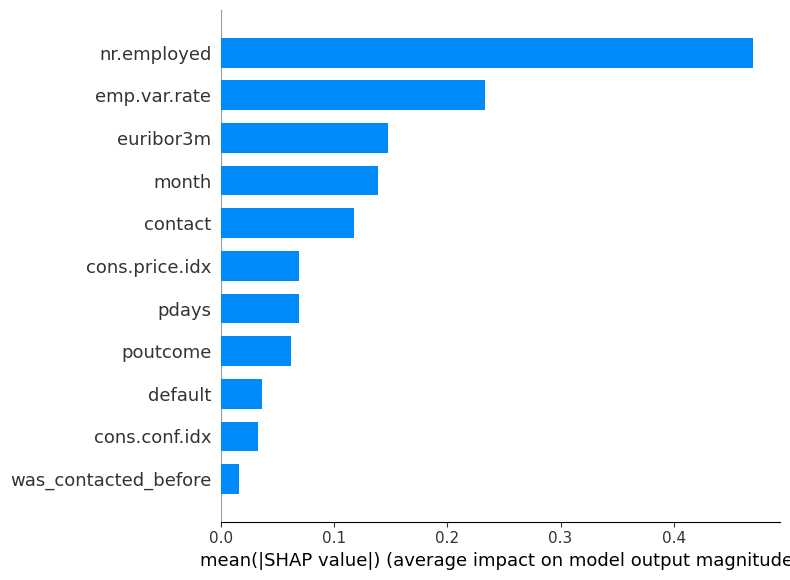

In [49]:
shap.summary_plot(shap_values, X_train_xgb_reduced, plot_type="bar")

/tmp/ipykernel_8499/1578346612.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_xgb_reduced,)


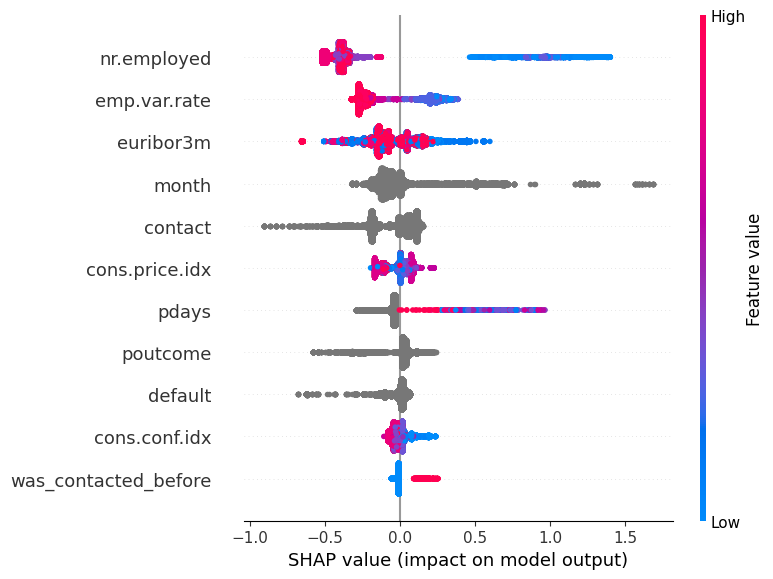

In [50]:
shap.summary_plot(shap_values, X_train_xgb_reduced,)

Згідно з SHAP-аналізом, найбільш впливовою ознакою для моделі є `nr.employed`, яка суттєво визначає результат передбачення.
Також значний внесок мають `emp.var.rate`, `euribor3m`, `month` та `contact`.
Інші ознаки, такі як `cons.price.idx`, `pdays` та `poutcome`, мають помірний вплив, тоді як решта факторів впливають незначно.
Загалом модель спирається переважно на невелику кількість ключових економічних та контактних характеристик.

# Best Model Error Analysis and Potential Improvements

In [55]:
y_pred = final_xgb_hyperopt_model.predict(X_valid_xgb_reduced)
y_proba  = final_xgb_hyperopt_model.predict_proba(X_valid_xgb_reduced)[:, 1]

error_analysis_df = X_valid_xgb_reduced.copy().reset_index(drop=True)
error_analysis_df["actual"] = val_targets_numerical.reset_index(drop=True)
error_analysis_df["predicted"] = y_pred
error_analysis_df["proba"] = y_proba

error_analysis_df["prediction_type"] = (
    error_analysis_df["actual"].astype(str) + "_" +
    error_analysis_df["predicted"].astype(str)
).map({
    "1_1": "TP",
    "0_0": "TN",
    "0_1": "FP",
    "1_0": "FN"
})

print("Prediction type distribution:")
display(error_analysis_df["prediction_type"].value_counts())

fp_df = error_analysis_df[error_analysis_df["prediction_type"] == "FP"].copy()
fn_df = error_analysis_df[error_analysis_df["prediction_type"] == "FN"].copy()
tp_df = error_analysis_df[error_analysis_df["prediction_type"] == "TP"].copy()
tn_df = error_analysis_df[error_analysis_df["prediction_type"] == "TN"].copy()


Prediction type distribution:


,count
prediction_type,
TN,7891
FP,1243
TP,748
FN,412


In [56]:
# Numeric features: FN vs TP
numeric_cols = X_valid_xgb_reduced.select_dtypes(include="number").columns.tolist()

fn_vs_tp_mean = pd.DataFrame({
    "TP_mean": tp_df[numeric_cols].mean(),
    "FN_mean": fn_df[numeric_cols].mean()
})

fn_vs_tp_mean["difference"] = fn_vs_tp_mean["FN_mean"] - fn_vs_tp_mean["TP_mean"]
fn_vs_tp_mean["abs_difference"] = fn_vs_tp_mean["difference"].abs()

print("Top numeric differences between FN and TP (mean values):")
display(
    fn_vs_tp_mean
    .sort_values("abs_difference", ascending=False)
    .head(10)
)

Top numeric differences between FN and TP (mean values):


,TP_mean,FN_mean,difference,abs_difference
nr.employed,5044.350401,5181.657767,137.307366,137.307366
cons.conf.idx,-38.725802,-41.608495,-2.882693,2.882693
euribor3m,1.085190,3.812029,2.726839,2.726839
emp.var.rate,-2.209225,0.316019,2.525244,2.525244
cons.price.idx,93.181579,93.584867,0.403288,0.403288
was_contacted_before,0.308824,0.000000,-0.308824,0.308824
pdays,5.757576,NaN,NaN,NaN


In [58]:
# Numeric features: FP vs TN
fp_vs_tn_mean = pd.DataFrame({
    "TN_mean": tn_df[numeric_cols].mean(),
    "FP_mean": fp_df[numeric_cols].mean()
})

fp_vs_tn_mean["difference"] = fp_vs_tn_mean["FP_mean"] - fp_vs_tn_mean["TN_mean"]
fp_vs_tn_mean["abs_difference"] = fp_vs_tn_mean["difference"].abs()

print("Top numeric differences between FP and TN (mean values):")
display(
    fp_vs_tn_mean
    .sort_values("abs_difference", ascending=False)
    .head(10)
)

Top numeric differences between FP and TN (mean values):


,TN_mean,FP_mean,difference,abs_difference
nr.employed,5194.188734,5068.161947,-126.026787,126.026787
euribor3m,4.243909,1.242815,-3.001094,3.001094
emp.var.rate,0.643264,-2.133709,-2.776973,2.776973
pdays,6.777778,5.600000,-1.177778,1.177778
cons.price.idx,93.700386,93.035755,-0.664632,0.664632
cons.conf.idx,-40.537625,-40.929284,-0.391659,0.391659
was_contacted_before,0.001141,0.108608,0.107468,0.107468


In [59]:
# Categorical features analysis
selected_categorical_cols = [
    col for col in ["contact", "month", "poutcome"]
    if col in X_valid_xgb_reduced.columns
]

print("Categorical columns used:")
print(selected_categorical_cols)

Categorical columns used:
['contact', 'month', 'poutcome']


In [60]:
for col in selected_categorical_cols:
    print(f"\nDistribution of '{col}' for TP vs FN:")

    display(
        error_analysis_df[error_analysis_df["prediction_type"].isin(["TP", "FN"])]
        .groupby("prediction_type")[col]
        .value_counts(normalize=True)
        .rename("share")
        .reset_index()
    )


Distribution of 'contact' for TP vs FN:


,prediction_type,contact,share
0,FN,cellular,0.699029
1,FN,telephone,0.300971
2,TP,cellular,0.898396
3,TP,telephone,0.101604



Distribution of 'month' for TP vs FN:


,prediction_type,month,share
0,FN,may,0.385922
1,FN,jul,0.228155
2,FN,aug,0.157767
3,FN,jun,0.114078
4,FN,nov,0.080097
5,FN,apr,0.031553
6,FN,sep,0.002427
7,FN,dec,0.000000
8,FN,mar,0.000000
9,FN,oct,0.000000



Distribution of 'poutcome' for TP vs FN:


,prediction_type,poutcome,share
0,FN,nonexistent,0.898058
1,FN,failure,0.101942
2,FN,success,0.000000
3,TP,nonexistent,0.550802
4,TP,success,0.286096
5,TP,failure,0.163102


In [61]:
for col in selected_categorical_cols:
    print(f"\nDistribution of '{col}' for TN vs FP:")

    display(
        error_analysis_df[error_analysis_df["prediction_type"].isin(["TN", "FP"])]
        .groupby("prediction_type")[col]
        .value_counts(normalize=True)
        .rename("share")
        .reset_index()
    )


Distribution of 'contact' for TN vs FP:


,prediction_type,contact,share
0,FP,cellular,0.861625
1,FP,telephone,0.138375
2,TN,cellular,0.564187
3,TN,telephone,0.435813



Distribution of 'month' for TN vs FP:


,prediction_type,month,share
0,FP,apr,0.296862
1,FP,may,0.155270
2,FP,aug,0.108608
3,FP,jun,0.107804
4,FP,nov,0.081255
5,FP,oct,0.079646
6,FP,mar,0.050684
7,FP,sep,0.050684
8,FP,jul,0.049075
9,FP,dec,0.020113



Distribution of 'poutcome' for TN vs FP:


,prediction_type,poutcome,share
0,FP,nonexistent,0.725664
1,FP,failure,0.178600
2,FP,success,0.095736
3,TN,nonexistent,0.916234
4,TN,failure,0.082753
5,TN,success,0.001014


In [63]:
# Most confident errors
print("Most confident False Positives:")
display(fp_df.sort_values("proba", ascending=False).head(5))

print("Most confident False Negatives:")
display(fn_df.sort_values("proba", ascending=True).head(5))

Most confident False Positives:


,default,contact,month,pdays,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,actual,predicted,proba,prediction_type
6160,no,cellular,mar,7.0,success,-1.8,93.369,-34.8,0.653,5008.7,1,0,1,0.945242,FP
10123,no,cellular,sep,6.0,success,-1.1,94.199,-37.5,0.879,4963.6,1,0,1,0.943421,FP
5057,no,cellular,sep,6.0,success,-1.1,94.199,-37.5,0.877,4963.6,1,0,1,0.943421,FP
2850,no,cellular,sep,6.0,success,-1.1,94.199,-37.5,0.882,4963.6,1,0,1,0.943421,FP
10007,no,cellular,jul,3.0,success,-1.7,94.215,-40.3,0.797,4991.6,1,0,1,0.943063,FP


Most confident False Negatives:


,default,contact,month,pdays,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,actual,predicted,proba,prediction_type
176,no,telephone,jul,NaN,nonexistent,1.4,93.918,-42.7,4.968,5228.1,0,1,0,0.146081,FN
3866,no,telephone,jul,NaN,nonexistent,1.4,93.918,-42.7,4.966,5228.1,0,1,0,0.157977,FN
1098,no,telephone,may,NaN,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0,1,0,0.175810,FN
1689,no,telephone,may,NaN,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0,1,0,0.175810,FN
10015,no,telephone,may,NaN,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0,1,0,0.175810,FN


Аналіз помилок показав, що модель краще розпізнає негативний клас, що частково зумовлено дисбалансом даних, однак допускає значну кількість хибнопозитивних прогнозів. При цьому помилки мають системний характер: FN частіше виникають для клієнтів без попередніх контактів (poutcome = nonexistent) та при telephone, тоді як FP — для клієнтів із ознаками, подібними до позитивного класу (наприклад, cellular та наявність попередніх контактів).

Це свідчить про те, що модель не повністю розрізняє близькі за характеристиками групи клієнтів, тому її якість можна покращити за рахунок додаткового feature engineering, кращої роботи з категоріальними ознаками та оптимізації порогу класифікації.

# Final Conclusions and Model Comparison Table

In [69]:
all_experiments_df = pd.concat([
    baseline_results_df,
    rand_search_results_df,
    hyperopt_results_df
], ignore_index=True)

all_experiments_df

,model,approach,threshold,cv_roc_auc,cv_average_precision,cv_f1,cv_recall,valid_roc_auc,valid_average_precision,valid_f1,valid_recall,params
0,Logistic Regression,baseline,0.500000,0.788458,0.446911,0.452343,0.622017,0.802032,0.443574,0.463316,0.639655,"{'C': 1.0, 'class_weight': 'balanced', 'dual':..."
1,XGBoost,baseline,0.500000,0.773166,0.426212,0.447924,0.571140,0.790838,0.451555,0.472752,0.609483,"{'objective': 'binary:logistic', 'base_score':..."
2,kNN,baseline,0.500000,0.722670,0.317488,0.371364,0.286287,0.739928,0.339067,0.373639,0.281034,"{'algorithm': 'auto', 'leaf_size': 30, 'metric..."
3,Decision Tree,baseline,0.500000,0.622882,0.182910,0.325684,0.339469,0.614064,0.176315,0.312158,0.319828,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',..."
4,XGBoost,random_search,0.500000,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.492881,0.626724,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
5,XGBoost,random_search + threshold,0.646465,0.797221,0.461103,0.478429,0.607071,0.815164,0.483920,0.523625,0.582759,"{'subsample': 0.9, 'n_estimators': 200, 'min_c..."
6,XGBoost,random_search + reduced_features,0.500000,0.798611,0.457616,0.472116,0.618568,0.812541,0.471758,0.475279,0.642241,"{'objective': 'binary:logistic', 'base_score':..."
7,Logistic Regression,random_search,0.500000,0.788983,0.446846,0.449248,0.621442,0.802239,0.446879,0.462779,0.643103,"{'model__solver': 'liblinear', 'model__penalty..."
8,XGBoost,hyperopt + reduced_features,0.500000,0.797899,0.459504,0.463243,0.631212,0.811922,0.473162,0.474770,0.644828,"{'objective': 'binary:logistic', 'base_score':..."
9,XGBoost,hyperopt + reduced_features + threshold,0.636364,0.797899,0.459504,0.463243,0.631212,0.811922,0.473162,0.520486,0.591379,{'best_params': {'colsample_bytree': 0.7384568...


У ході виконання проєкту було побудовано та порівняно кілька моделей машинного навчання для задачі прогнозування підписки клієнта на депозит. Базові моделі показали обмежену якість, тоді як використання XGBoost разом із підбором гіперпараметрів (зокрема Hyperopt) дозволило досягти кращих результатів та більш збалансованої якості прогнозів.

Фінальна модель продемонструвала хорошу здатність ранжувати спостереження, однак аналіз помилок показав, що вона все ще має труднощі з розділенням схожих за характеристиками клієнтів. Зокрема, модель частіше допускає помилки для клієнтів без попередніх контактів (poutcome = nonexistent) та при використанні telephone, що призводить до пропуску частини позитивного класу (FN). Водночас значна кількість хибнопозитивних прогнозів (FP) свідчить про те, що модель іноді переоцінює ймовірність підписки для клієнтів із ознаками, подібними до цільової групи.

Таким чином, попри загалом хорошу якість моделі, результати вказують на необхідність подальшого вдосконалення. Потенційні напрямки покращення включають створення додаткових ознак, більш детальну обробку категоріальних змінних, а також оптимізацію порогу класифікації для досягнення кращого балансу між recall та precision.